Script to post-process timer outputs
on cooling energy and cooling gap

In [2]:
# import packages 
import os
import pandas as pd
import pym
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
MAIN_DIR = r'X:\user\crassierc'

OUTPUT_DIR = os.path.join(MAIN_DIR, r'Projects\PRISMA\2_TIMER\outputlib\TIMER_3_4\PRISMA')
IMAGE_REGION_MAPPING_DIR = os.path.join(MAIN_DIR, r'code\geospatial-metadata\mappings')

RESIDENTIAL_DIR = os.path.join(OUTPUT_DIR, r'{}\T2RT\endem\residential')
TUSS_RES_DIR = os.path.join(OUTPUT_DIR, r'{}\tuss\endem\residential')
COOLING_GAP_DIR = os.path.join(OUTPUT_DIR, r'{}\cooling_gap')

os.chdir(MAIN_DIR)

In [4]:
# load timer output data
appliance_diffusion_fp = os.path.join(TUSS_RES_DIR, 'res_diffusion.out')          # [27,13,11]
energy_use_fp = os.path.join(RESIDENTIAL_DIR, 'ApplEnUse.out')                        # [27,13,12]
heat_exposed_share_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat_share.out')   # [26,4]: take median of the the second dimension
heat_exposed_pop_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat.out')
heat_exposed_pop_median_fp = os.path.join(COOLING_GAP_DIR, 'exposed_pop_heat_median.out')
cooling_gap_pop_fp = os.path.join(COOLING_GAP_DIR, 'cooling_gap_pop.out')             # [27,13,3]
cooling_gap_pop_share_fp = os.path.join(COOLING_GAP_DIR, 'cooling_gap_pop_share.out')             # [27,13,3]
appliance_saturation_fp = os.path.join(COOLING_GAP_DIR, 'saturation_cooling.out')

scenarios = [
    'SSP2','NO_GAP', 'NO_GAP_ELEC', 'NO_GAP_SUST',
    'SSP2_20D', 'NO_GAP_20D', 'NO_GAP_ELEC_20D', 'NO_GAP_SUST_20D']
filepaths = {
   'appliance_diffusion': appliance_diffusion_fp,
   'energy_use': energy_use_fp,
   'heat_exposed_share': heat_exposed_share_fp,
   'heat_exposed_pop': heat_exposed_pop_fp,
   'heat_exposed_pop_median': heat_exposed_pop_median_fp,
   'cooling_gap_pop': cooling_gap_pop_fp,
   'cooling_gap_pop_share': cooling_gap_pop_share_fp,
   'appliance_saturation': appliance_saturation_fp
}

# load image region mapping data
region_mapping_fp = os.path.join(IMAGE_REGION_MAPPING_DIR, r'country_to_regions.csv')
region_numbers_fp = os.path.join(IMAGE_REGION_MAPPING_DIR, r'image_region_numbers.csv')

region_mapping = pd.read_csv(region_mapping_fp, encoding='latin-1')
region_numbers = pd.read_csv(region_numbers_fp)

In [5]:
# load mym output file as array of tuples
def load_files(fp):
    file = pym.read_mym(fp)
    return file

# convert tuple data into xarray dataarray
def create_dataarray(data_tuple):

    data, years = data_tuple
    shape = data.shape
    
    # Create coordinate arrays
    dims = ['year']
    coords = {'year': years}
    dim_names = ['region', 'dim2', 'dim3', 'dim4']
    
    for i, dim_size in enumerate(shape[1:]):
        if i < len(dim_names):
            dim_name = dim_names[i]
            dims.append(dim_name)
            coords[dim_name] = list(range(dim_size))
    
    # Create the DataArray with dynamic dimensions
    da = xr.DataArray(
        data=data,
        dims=dims,
        coords=coords
    )
    
    return da

In [6]:
# loads data and converts to dataarrays

def load_data_as_arrays(filepaths, scenarios):
    result = {}

    for scenario in scenarios:
        result[scenario] = {}

        for name, path_template in filepaths.items():
            formatted_path = path_template.format(scenario)
            data_tuple = load_files(formatted_path)
            result[scenario][name] = create_dataarray(data_tuple)
            
    return result

all_data = load_data_as_arrays(filepaths, scenarios)

In [43]:
# plot regional variables

def plot_regional_comparison(variable_data, labels, colors, title, y_label):
    rows, cols = 6,5
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16), sharex=True)
    axes = axes.flatten()
    
    years = variable_data[0]['year'].where(variable_data[0]['year']>2026)
    regions = variable_data[0]['region']

    for i, region in enumerate(regions):
        if i < len(axes):
            ax = axes[i]
            
            for j, dim_data in enumerate(variable_data):
                data = dim_data.sel(region=region)
                ax.plot(years, data, color=colors[j], label=labels[j] if i == 0 else '')
            
            ax.set_title(f'Region {region.values+1}')
            ax.set_ylim(0, 1.1)
            ax.grid(True, linestyle='--', alpha=0.7)
            if i % cols == 0:
                ax.set_ylabel(y_label)
    
    for i in range(len(regions), len(axes)):
        axes[i].set_visible(False)
    
    fig.text(0.04, 0.5, y_label, va='center', rotation='vertical', fontsize=14)
    fig.legend(labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3)
    fig.suptitle(title, fontsize=16)
    
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

Look into urban/rural divide for cooling gap

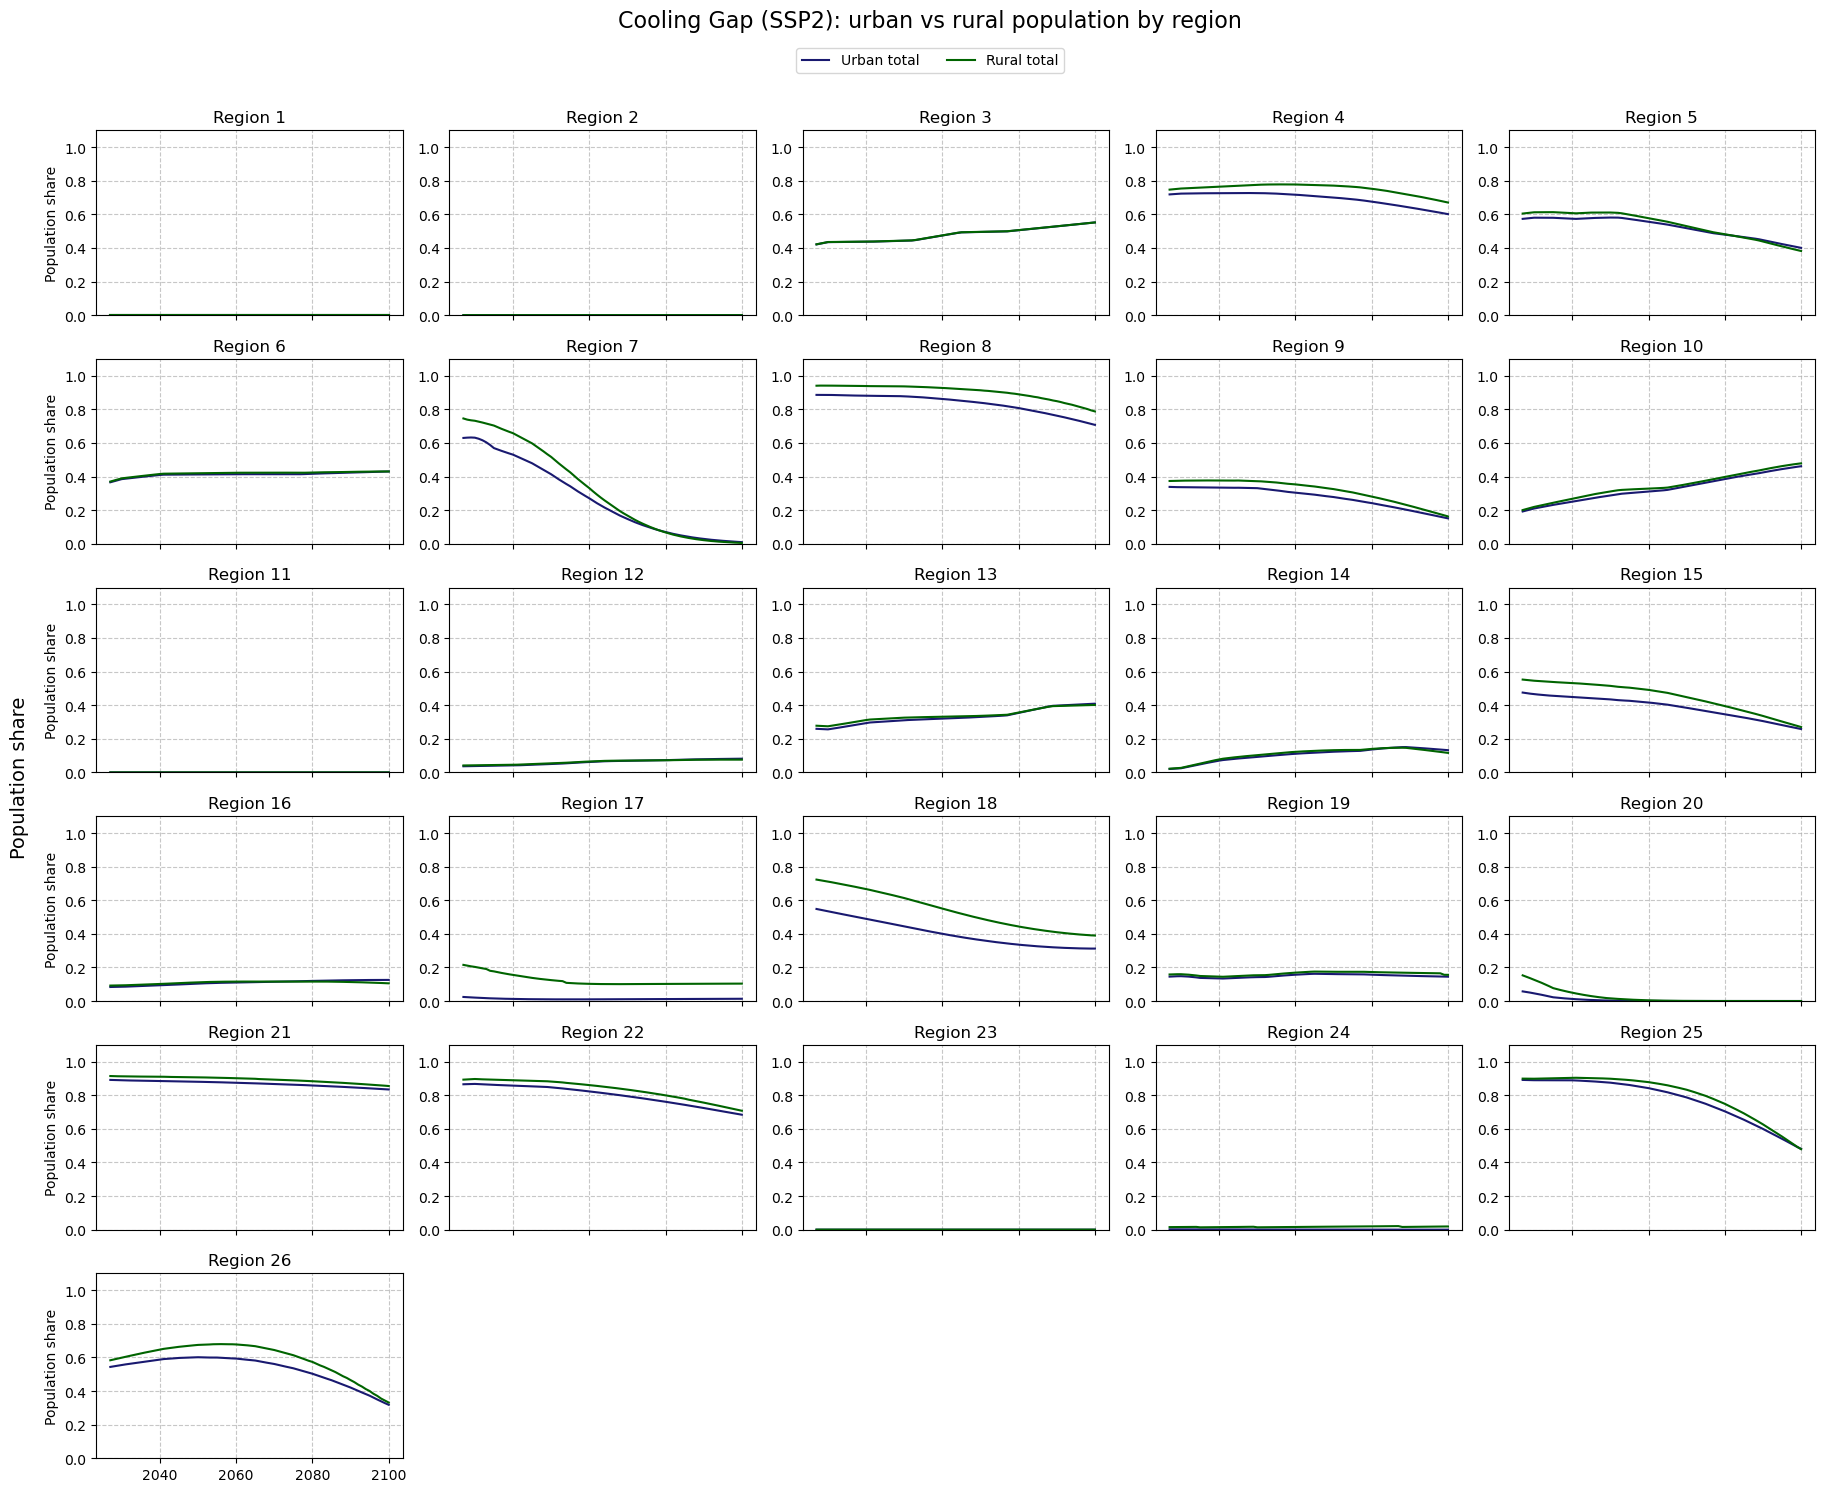

In [45]:
urban_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=1, dim3=2)
rural_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=2, dim3=2)

plot_regional_comparison(
    variable_data=[urban_data, rural_data],
    labels=['Urban total', 'Rural total'],
    colors=['midnightblue', 'Darkgreen'],
    title='Cooling Gap (SSP2): urban vs rural population by region',
    y_label='Population share'
)

Look into income inequalities for cooling gap

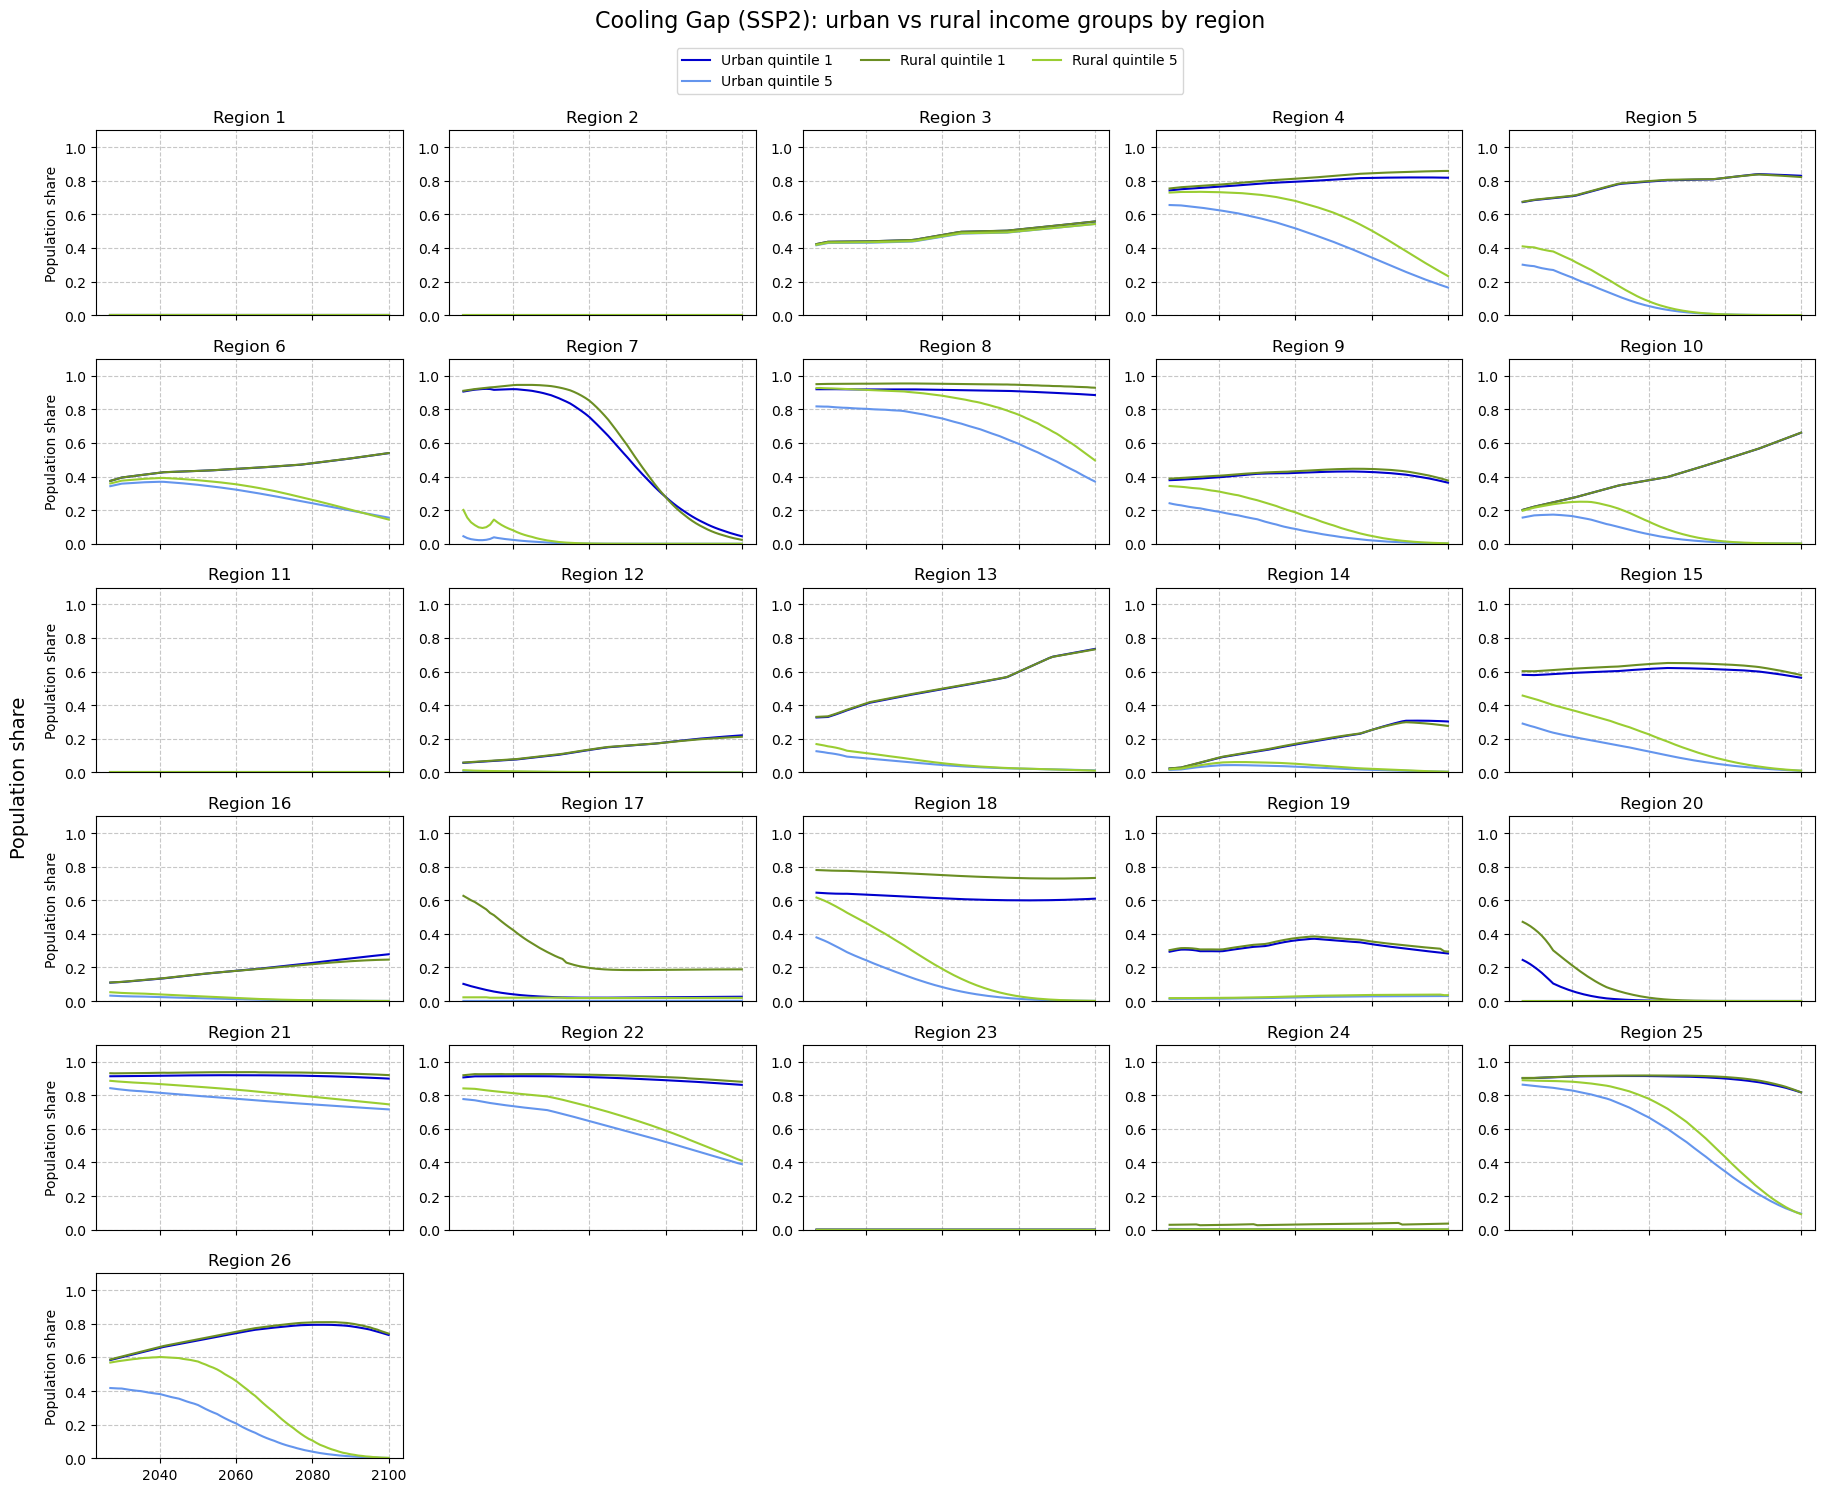

In [46]:
urban_1_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=3, dim3=2)
urban_5_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=7, dim3=2)
rural_1_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=8, dim3=2)
rural_5_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=12, dim3=2)

plot_regional_comparison(
    variable_data=[urban_1_data, urban_5_data, rural_1_data, rural_5_data],
    labels=['Urban quintile 1', 'Urban quintile 5', 'Rural quintile 1', 'Rural quintile 5'],
    colors=['mediumblue', 'cornflowerblue', 'olivedrab', 'yellowgreen'],
    title='Cooling Gap (SSP2): urban vs rural income groups by region',
    y_label='Population share'
)

Compare cooling gap under baseline and mitigation scenarios across regions

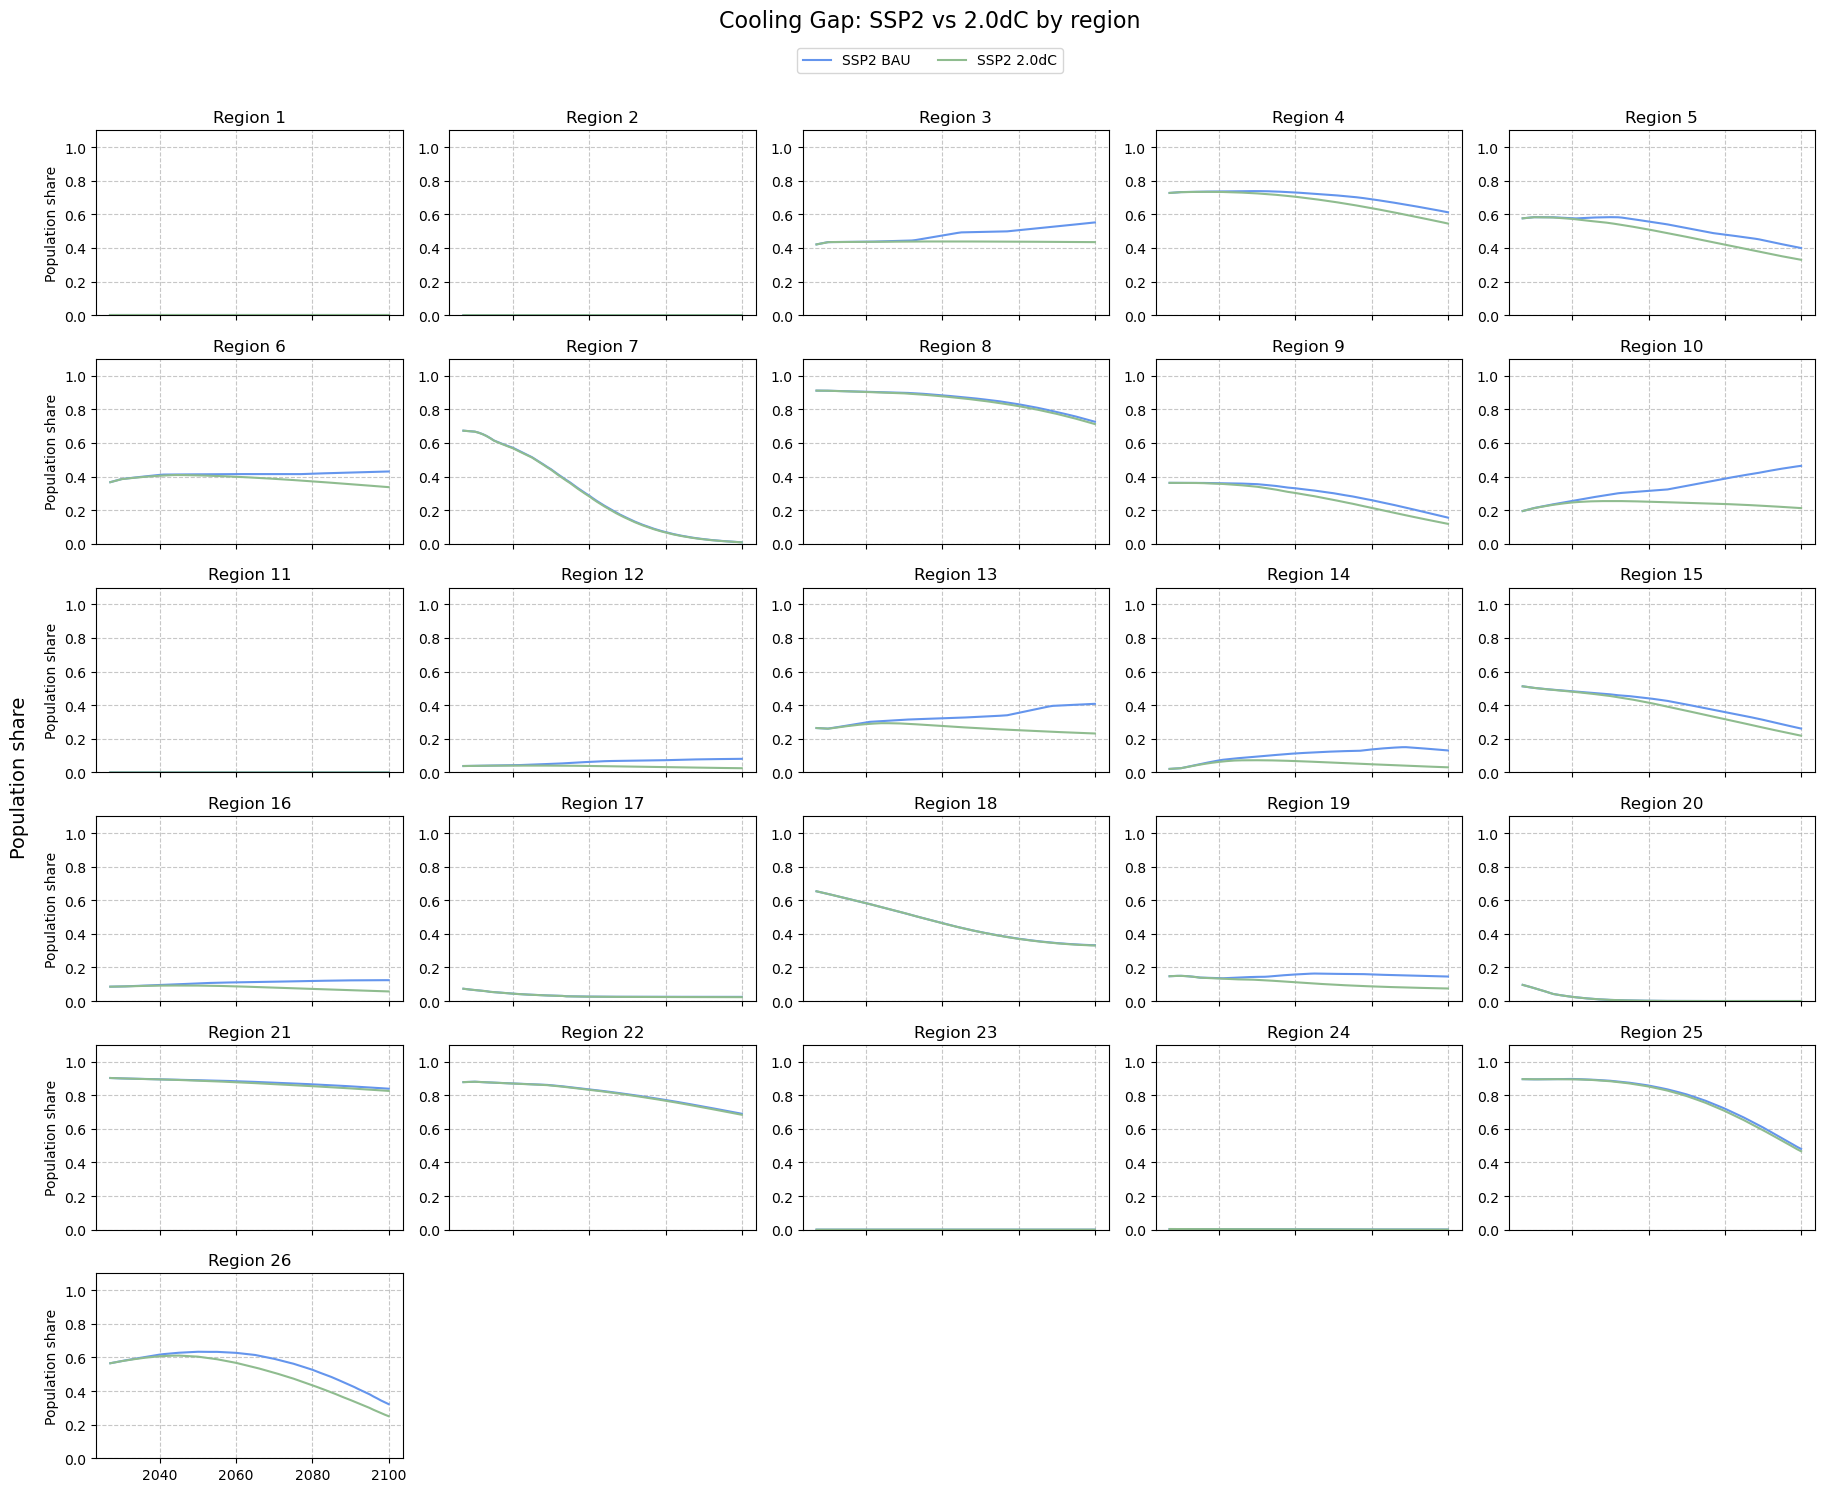

In [47]:
gap_ssp2_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=0, dim3=2)
gap_20d_data = all_data['SSP2_20D']['cooling_gap_pop_share'].sel(dim2=0, dim3=2)

plot_regional_comparison(
    variable_data=[gap_ssp2_data, gap_20d_data],
    labels=['SSP2 BAU', 'SSP2 2.0dC'],
    colors=['cornflowerblue', 'darkseagreen'],
    title='Cooling Gap: SSP2 vs 2.0dC by region',
    y_label='Population share'
)

Compare cooling gap to diffusion, saturation and heat stress under SSP2 scenario

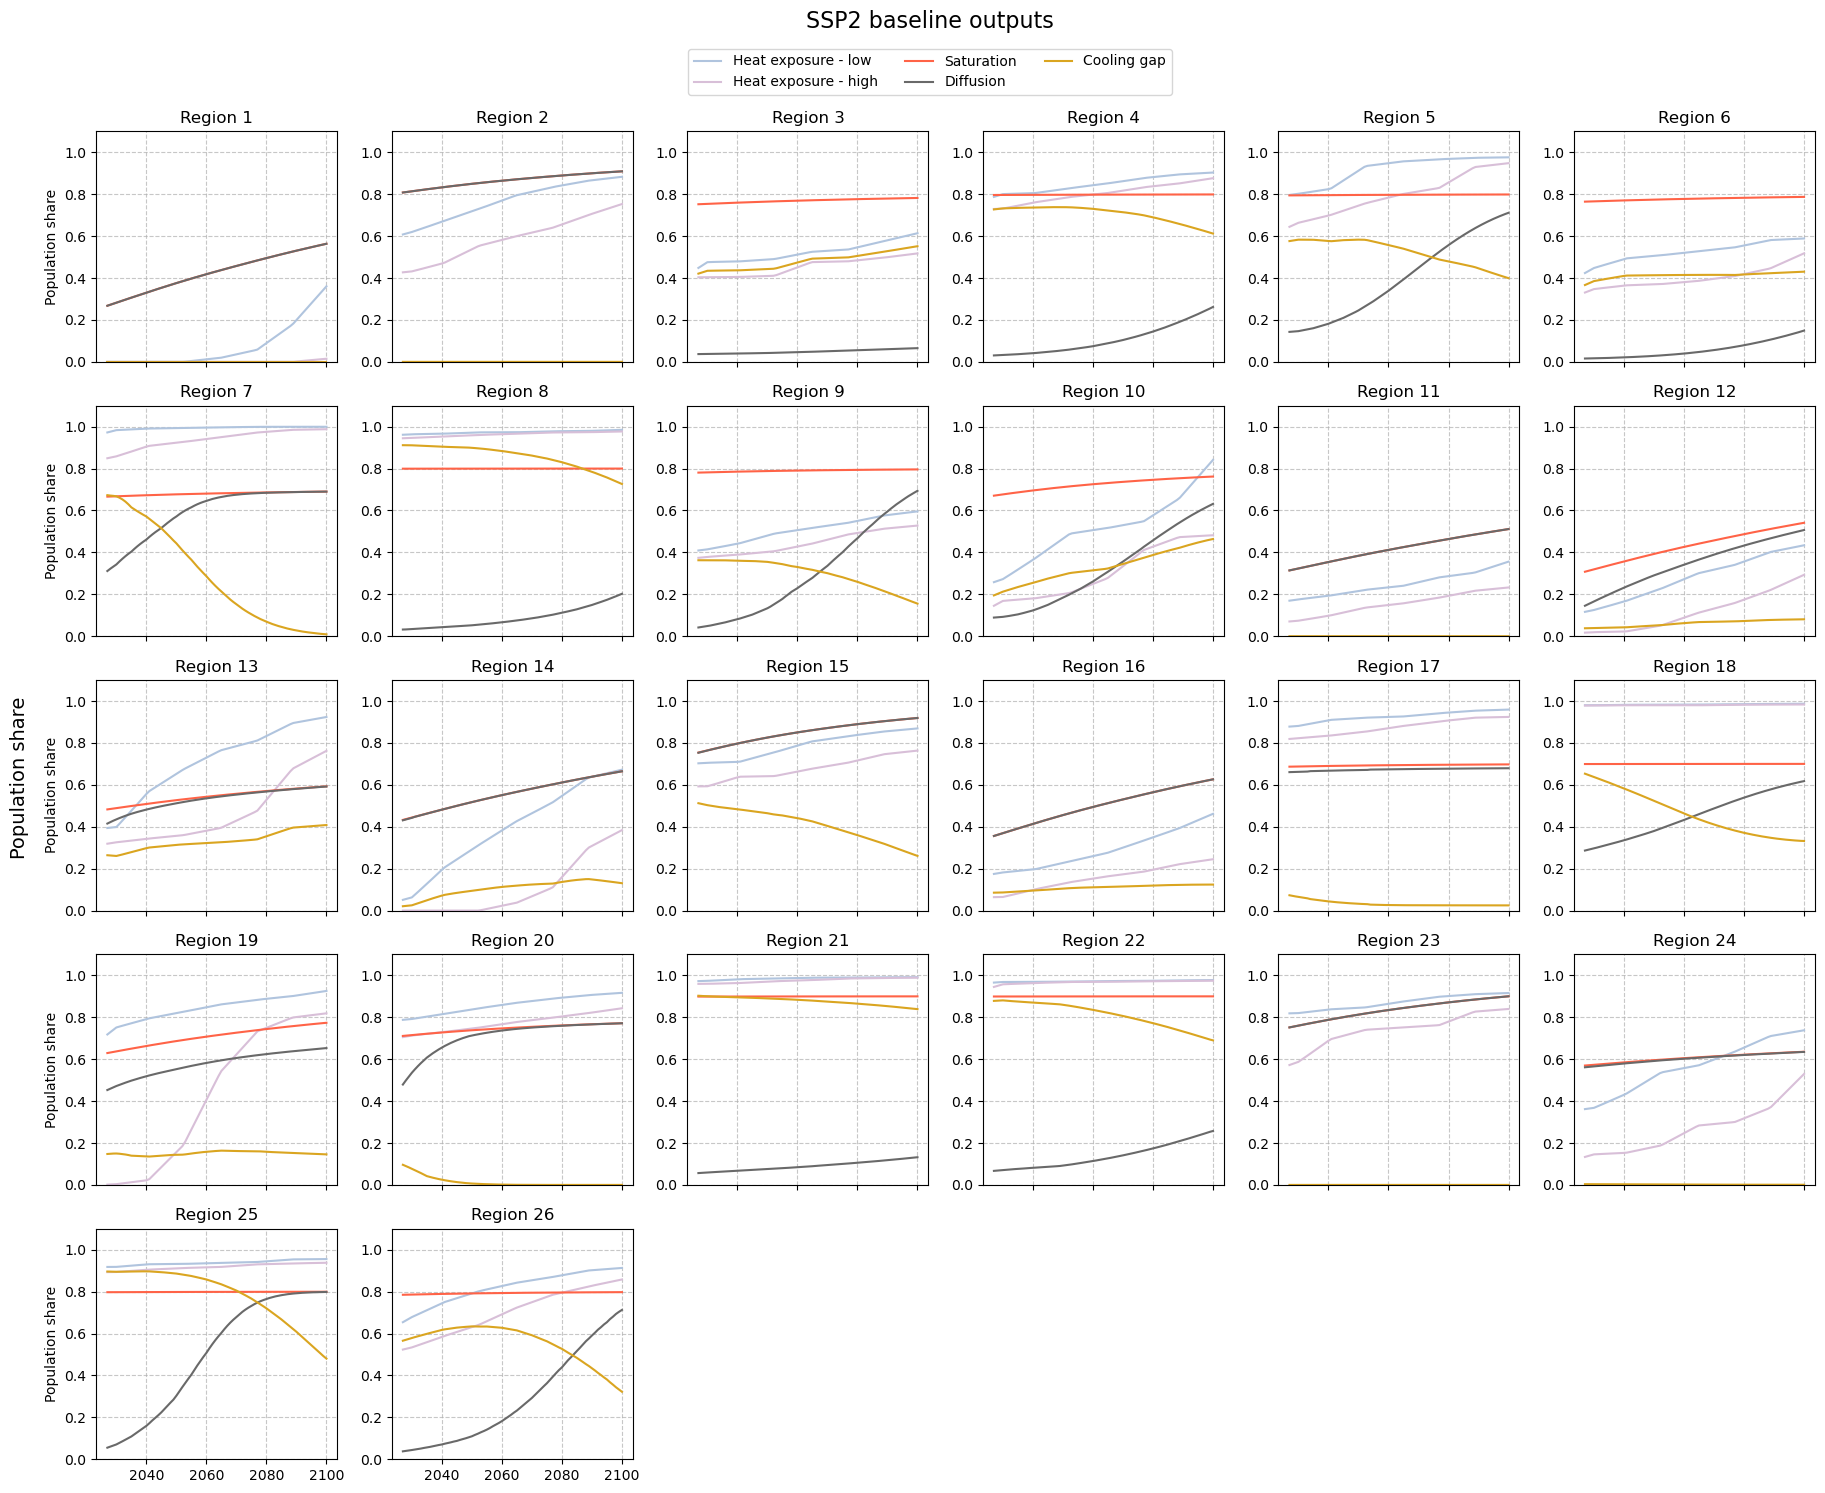

In [41]:
gap_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=0, dim3=2)
diffusion_data = all_data['SSP2']['appliance_diffusion'].sel(dim2=0, dim3=2)
saturation_data = all_data['SSP2']['appliance_saturation'].sel(dim2=0, dim3=2)
heat_exposure_low_data = all_data['SSP2']['heat_exposed_share'].sel(dim2=1)
heat_exposure_high_data = all_data['SSP2']['heat_exposed_share'].sel(dim2=2)

plot_regional_comparison(
    variable_data=[heat_exposure_low_data, heat_exposure_high_data, saturation_data, diffusion_data, gap_data],
    labels=['Heat exposure - low', 'Heat exposure - high', 'Saturation', 'Diffusion', 'Cooling gap'],
    colors=['lightsteelblue', 'thistle', 'tomato', 'dimgray', 'goldenrod'],
    title='SSP2 baseline outputs',
    y_label='Population share'
)

In [89]:
# plot global variables

def plot_global_comparison(variable_data, labels, colors, title, y_label):
    
    rows, cols = 1,1
    fig, ax = plt.subplots(rows, cols, figsize=(8,6))
    
    years = variable_data[0]['year'].where(variable_data[0]['year']>2026)

    for i, dim_data in enumerate(variable_data):
        data = dim_data
        ax.plot(years, data, color=colors[i], label=labels[i] if i == 0 else '')

    ax.set_ylim(0, 1.1)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    fig.text(0.04, 0.5, y_label, va='center', rotation='vertical', fontsize=14)
    fig.legend(labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=3)
    fig.suptitle(title, fontsize=16)
    
    plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

Compare global population in the cooling gap under baseline and mitigation SSP2 scenarios

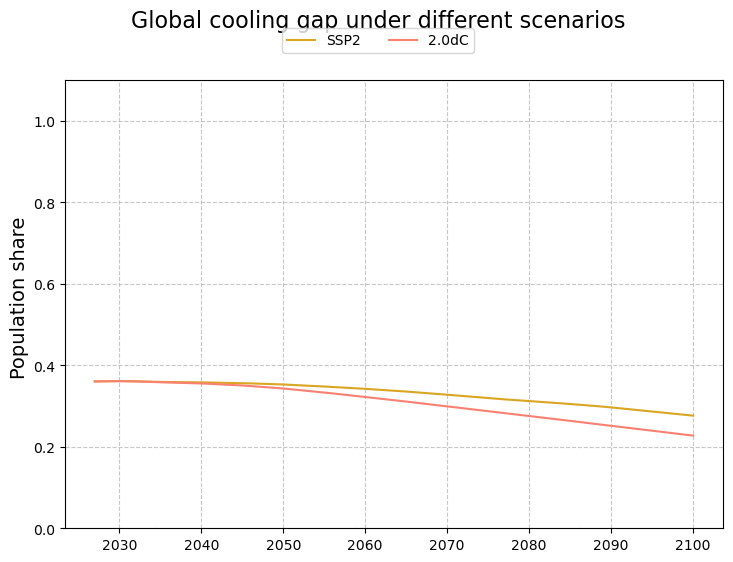

In [90]:
# TODO: this is the simple average across regions, i need to calculate population-weighted average
gap_ssp2_data = all_data['SSP2']['cooling_gap_pop_share'].sel(dim2=0, dim3=2).mean('region')
gap_20dC_data = all_data['SSP2_20D']['cooling_gap_pop_share'].sel(dim2=0, dim3=2).mean('region')

plot_global_comparison(
    variable_data=[gap_ssp2_data, gap_20dC_data],
    labels=['SSP2', '2.0dC'],
    colors=['goldenrod', 'salmon'],
    title='Global cooling gap under different scenarios',
    y_label='Population share'
)